In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/uciml/mushroom-classification/mushrooms.csv


In [2]:
df=pd.read_csv("/kaggle/input/datasets/uciml/mushroom-classification/mushrooms.csv")

In [3]:
df.head(3)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [5]:
df=pd.get_dummies(df,columns=["class","stalk-surface-above-ring","cap-shape","cap-surface","cap-color","bruises","odor","gill-attachment","gill-spacing","gill-size","gill-color","stalk-surface-below-ring","stalk-shape","stalk-root","stalk-surface-below-ring","stalk-color-above-ring","stalk-color-below-ring","veil-type","veil-color","ring-number","ring-type","spore-print-color","population","habitat"],drop_first=True)

In [6]:
df.head(3)

,class_p,stalk-surface-above-ring_k,stalk-surface-above-ring_s,stalk-surface-above-ring_y,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_g,...,population_n,population_s,population_v,population_y,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,True,False,True,False,False,False,False,False,True,False,...,False,True,False,False,False,False,False,False,True,False
1,False,False,True,False,False,False,False,False,True,False,...,True,False,False,False,True,False,False,False,False,False
2,False,False,True,False,False,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,False


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 99 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   class_p                     8124 non-null   bool 
 1   stalk-surface-above-ring_k  8124 non-null   bool 
 2   stalk-surface-above-ring_s  8124 non-null   bool 
 3   stalk-surface-above-ring_y  8124 non-null   bool 
 4   cap-shape_c                 8124 non-null   bool 
 5   cap-shape_f                 8124 non-null   bool 
 6   cap-shape_k                 8124 non-null   bool 
 7   cap-shape_s                 8124 non-null   bool 
 8   cap-shape_x                 8124 non-null   bool 
 9   cap-surface_g               8124 non-null   bool 
 10  cap-surface_s               8124 non-null   bool 
 11  cap-surface_y               8124 non-null   bool 
 12  cap-color_c                 8124 non-null   bool 
 13  cap-color_e                 8124 non-null   bool 
 14  cap-colo

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [9]:
y=df["class_p"]
x=df.drop(columns=["class_p"])

In [10]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.01,random_state=42)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 99 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   class_p                     8124 non-null   bool 
 1   stalk-surface-above-ring_k  8124 non-null   bool 
 2   stalk-surface-above-ring_s  8124 non-null   bool 
 3   stalk-surface-above-ring_y  8124 non-null   bool 
 4   cap-shape_c                 8124 non-null   bool 
 5   cap-shape_f                 8124 non-null   bool 
 6   cap-shape_k                 8124 non-null   bool 
 7   cap-shape_s                 8124 non-null   bool 
 8   cap-shape_x                 8124 non-null   bool 
 9   cap-surface_g               8124 non-null   bool 
 10  cap-surface_s               8124 non-null   bool 
 11  cap-surface_y               8124 non-null   bool 
 12  cap-color_c                 8124 non-null   bool 
 13  cap-color_e                 8124 non-null   bool 
 14  cap-colo

In [12]:
rf=RandomForestClassifier()
model=rf.fit(x_train,y_train)

In [13]:
model.score(x_test,y_test)

1.0

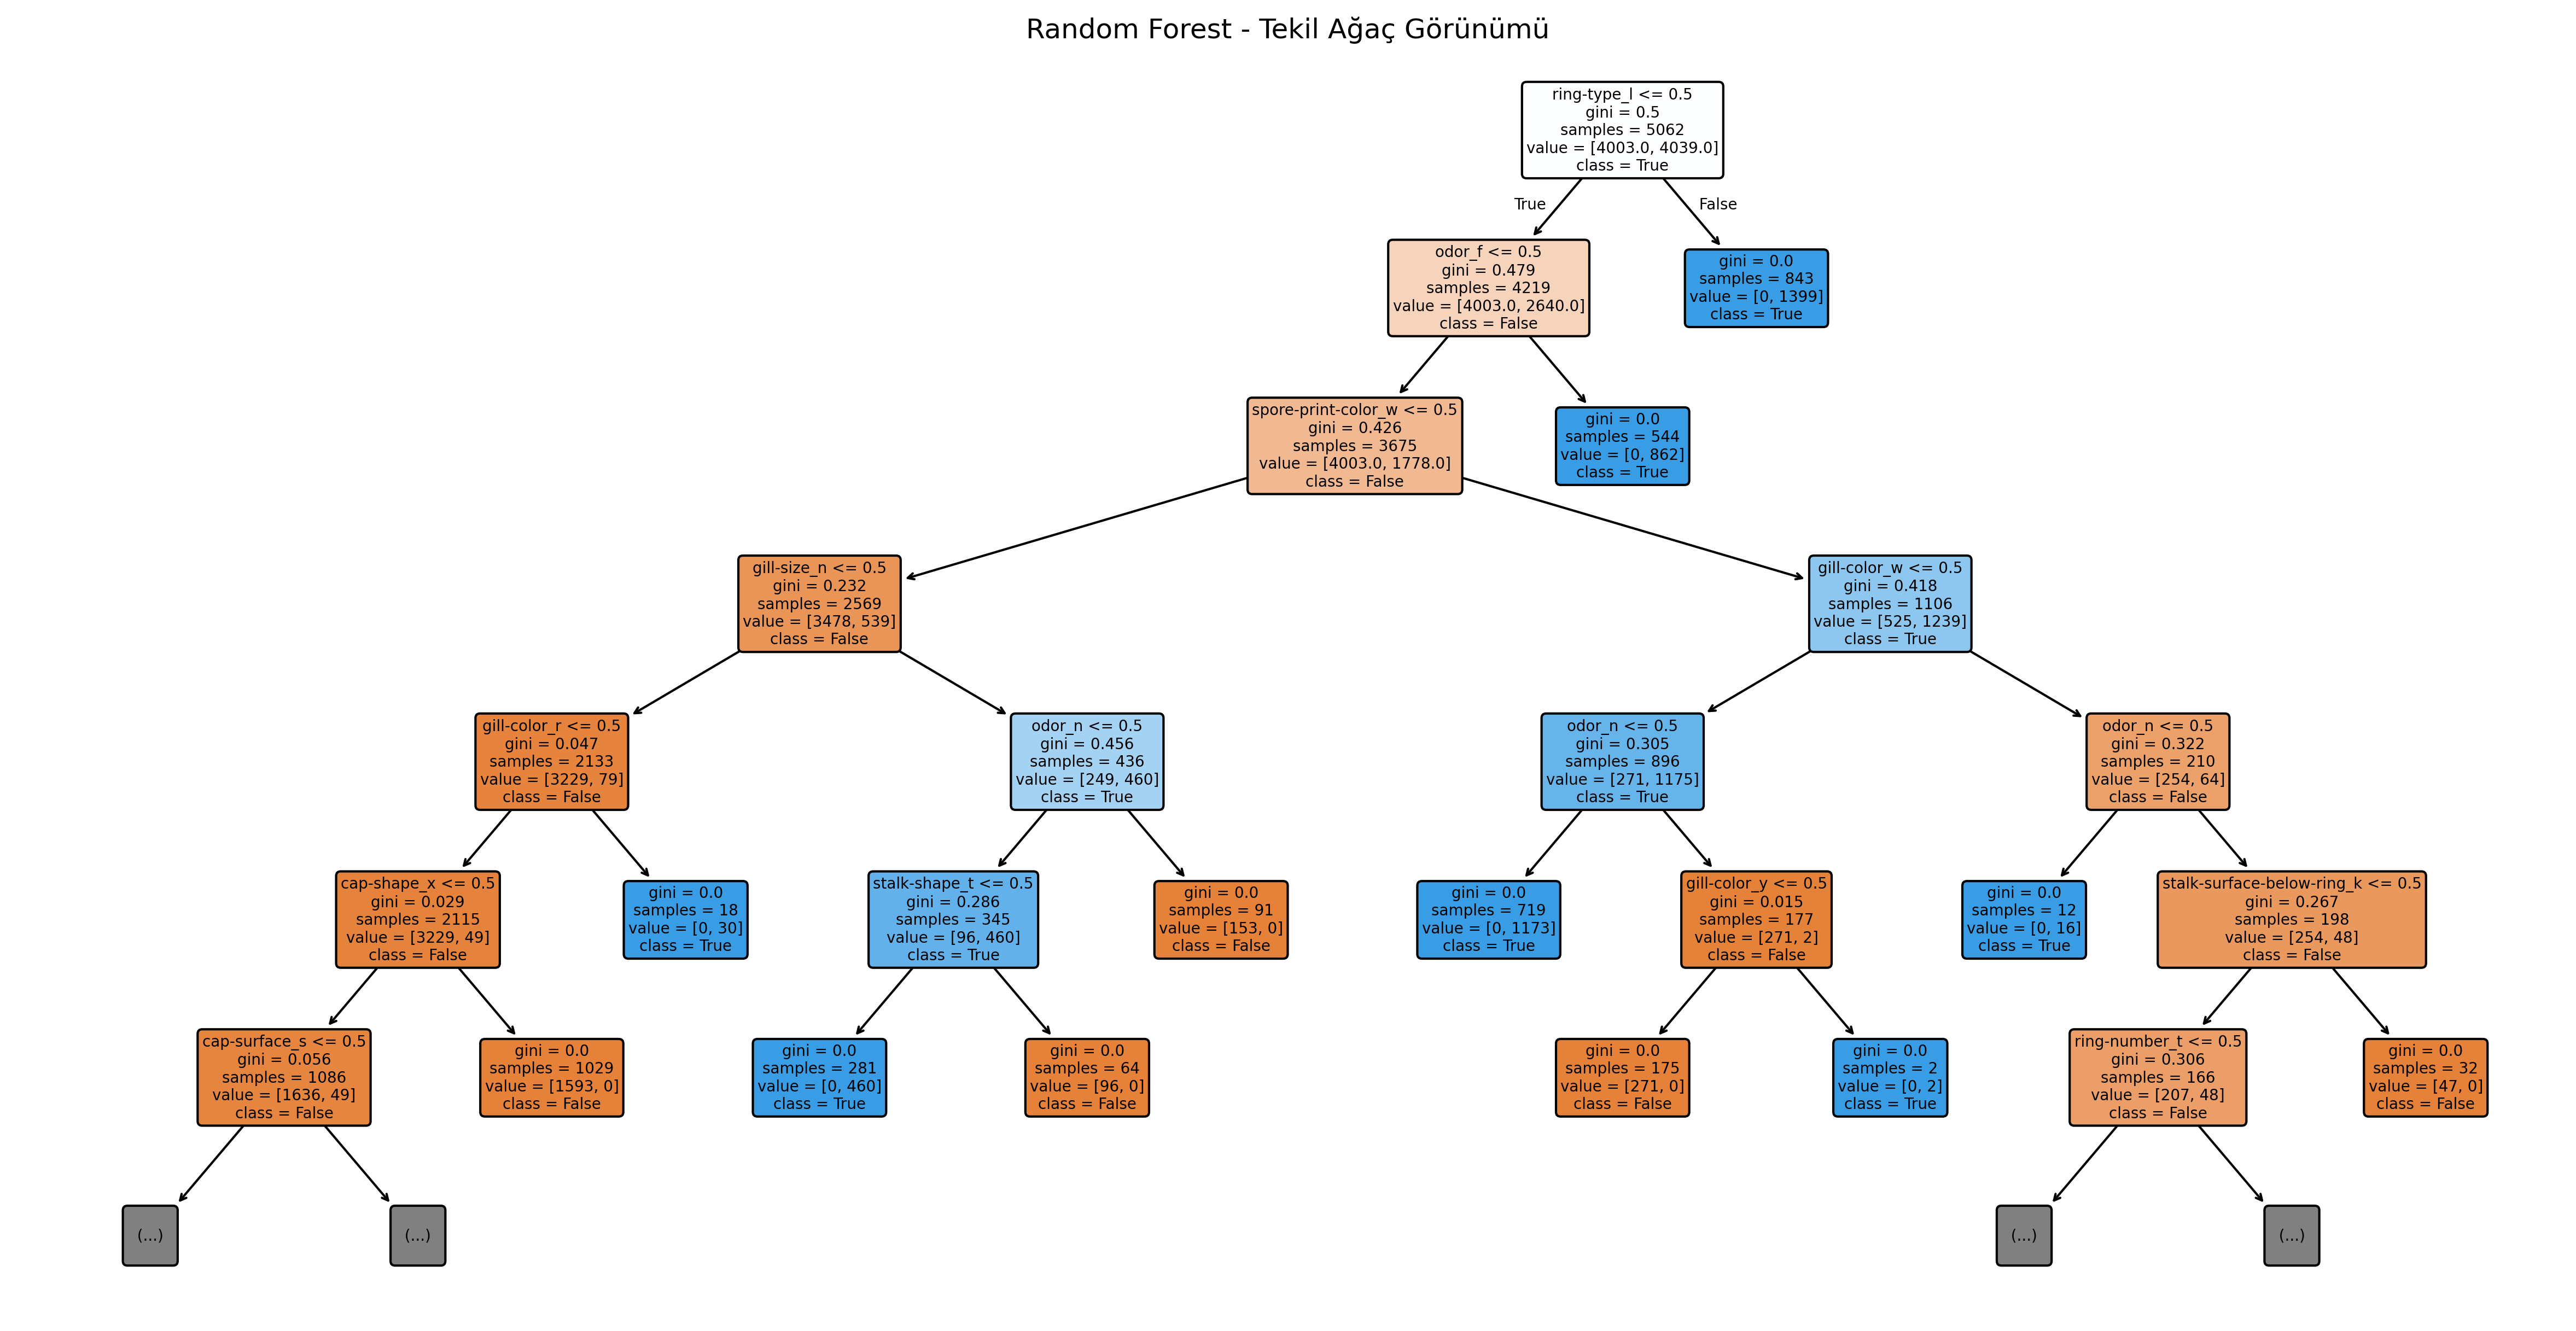

In [14]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Modelin ilk ağacını görselleştir
plt.figure(figsize=(20, 10), dpi=300)
plot_tree(
    model.estimators_[0],
    feature_names=x.columns,
    class_names=[str(c) for c in model.classes_],  # Sınıflandırma ise
    filled=True,
    rounded=True,
    max_depth=6  # Çok karmaşık olmaması için derinliği sınırlandırabilirsiniz
)
plt.title("Random Forest - Tekil Ağaç Görünümü")
plt.show()